## Step 0: Install and Import Libraries

In [1]:
import os
import json
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import torchvision
from torchvision import datasets, transforms
from torchvision.models import efficientnet_b0

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix, 
)

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)

Using device: cpu
PyTorch version: 2.14.0+cu130
Torchvision version: 0.29.0+cu130


## Step 1: Load and inspect the dataset

### Set folder path and read class names

In [3]:
DATA_DIR = "CivicIssuesImageDataset"
train_dir = os.path.join(DATA_DIR, "train")
val_dir = os.path.join(DATA_DIR, "validate")
test_dir = os.path.join(DATA_DIR, "test")

class_names = sorted(os.listdir(train_dir))
num_classes = len(class_names)
print("Classes:", class_names)
print("Number of classes:", num_classes)

Classes: ['Garbage_Waste_Trash', 'Infrastructure_Damage_Concrete', 'Parking_Issues_Illegal_Parking', 'Road_Issues_Damaged_Sign', 'Road_Issues_Pothole', 'Vandalism_Graffiti']
Number of classes: 6


### Count images per class and split

In [6]:
def count_images(split_dir):
    counts = {}
    for cls in sorted(os.listdir(split_dir)):
        cls_path = os.path.join(split_dir, cls)
        if os.path.isdir(cls_path):
            counts[cls] = len([
                f for f in os.listdir(cls_path)
                if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp"))
            ])
    return counts

count_df = pd.DataFrame({
    "train": count_images(train_dir),
    "validate": count_images(val_dir),
    "test": count_images(test_dir),
})

count_df["total"] = count_df.sum(axis=1)
print(count_df)
print("\nTotals:\n", count_df.sum())

                                train  validate  test  total
Garbage_Waste_Trash               982       300   302   1584
Infrastructure_Damage_Concrete    823       216   215   1254
Parking_Issues_Illegal_Parking   1285       223   232   1740
Road_Issues_Damaged_Sign         1927       241   241   2409
Road_Issues_Pothole              1130       292   290   1712
Vandalism_Graffiti               1232       220   222   1674

Totals:
 train        7379
validate     1492
test         1502
total       10373
dtype: int64


### Check for corrupt or unreadable images

In [10]:
bad_files = []
for split_dir in [train_dir, val_dir, test_dir]:
    for cls in os.listdir(split_dir):
        cls_path = os.path.join(split_dir, cls)
        if not os.path.isdir(cls_path):
            continue
        for f in os.listdir(cls_path):
            path = os.path.join(cls_path, f)
            try:
                with Image.open(path) as img:
                    img.verify()
            except Exception:
                bad_files.append(path)

print("Corrupt/unreadable files:", len(bad_files))
print(bad_files[:10])

Corrupt/unreadable files: 5
['CivicIssuesImageDataset/train/Garbage_Waste_Trash/IMG (1).mp4', 'CivicIssuesImageDataset/train/Garbage_Waste_Trash/IMG (2).mp4', 'CivicIssuesImageDataset/train/Garbage_Waste_Trash/IMG (3).mp4', 'CivicIssuesImageDataset/train/Garbage_Waste_Trash/IMG (4).mp4', 'CivicIssuesImageDataset/train/Garbage_Waste_Trash/IMG (5).mp4']


## Step 2: Exploratory Data Analysis

### Plot class distribution across splits

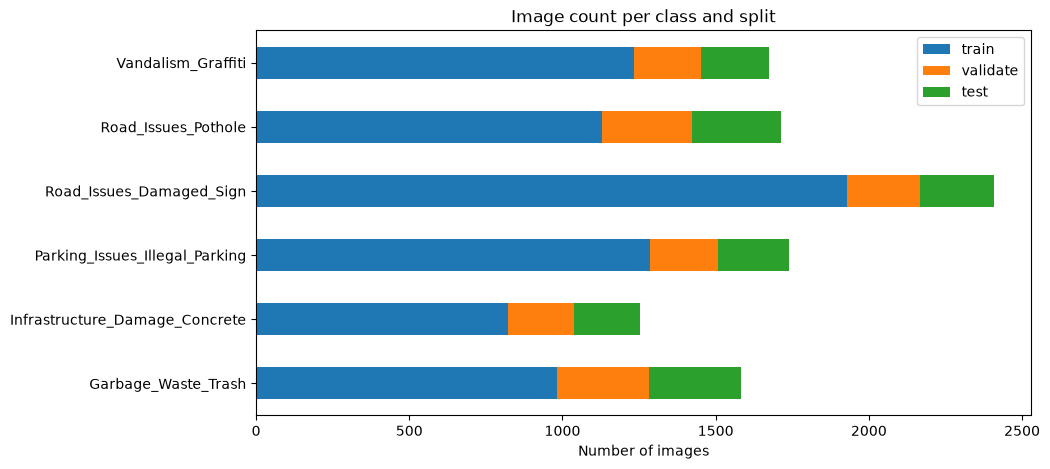

In [11]:
count_df[["train", "validate", "test"]].plot(kind="barh", stacked=True, figsize=(10,5))
plt.title("Image count per class and split")
plt.xlabel("Number of images")
plt.show()

### View sample images per class

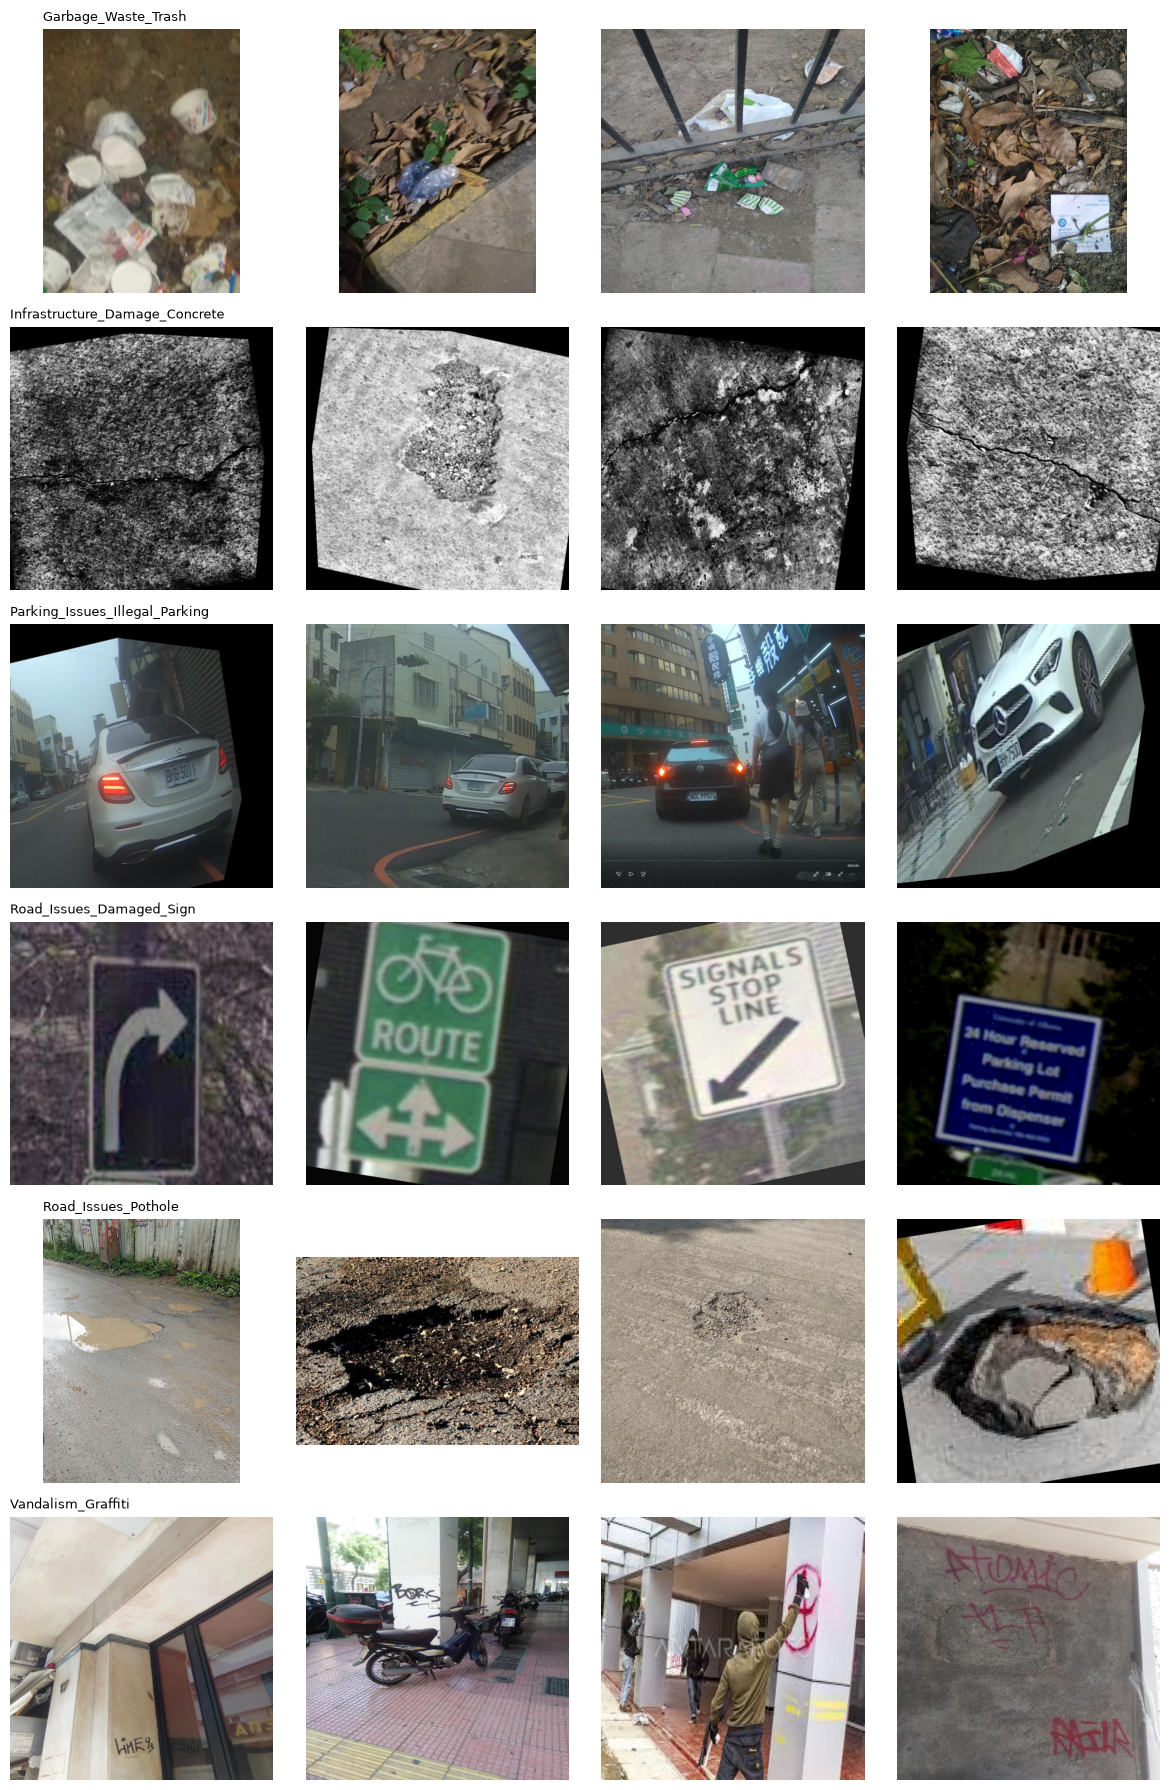

In [13]:
fig, axes = plt.subplots(num_classes, 4, figsize=(12,3 * num_classes))
for i, cls in enumerate(class_names):
    cls_path = os.path.join(train_dir, cls)
    files = random.sample(os.listdir(cls_path), min(4, len(os.listdir(cls_path))))
    for j, f in enumerate(files):
        img = Image.open(os.path.join(cls_path, f)).convert("RGB")
        axes[i][j].imshow(img)
        axes[i][j].axis("off")
        if j ==0:
            axes[i][j].set_title(cls, fontsize=9, loc="left")
plt.tight_layout()
plt.show()

### Check image size distribution

In [16]:
sizes = []
for cls in class_names:
    cls_path = os.path.join(train_dir, cls)
    files = os.listdir(cls_path)
    for f in random.sample(files, min(50, len(files))):
        with Image.open(os.path.join(cls_path, f)) as img:
            sizes.append(img.size)

size_df = pd.DataFrame(sizes, columns=["width", "height"])
print(size_df.describe())

             width       height
count   300.000000   300.000000
mean   1024.096667  1171.740000
std     896.094962  1267.689524
min     400.000000   300.000000
25%     640.000000   640.000000
50%     640.000000   640.000000
75%     640.000000   640.000000
max    3468.000000  4624.000000


## Step 3: Define Image Transforms (Preprocessing and Augmentation)

### Resizes every image to 224×224 (EfficientNet-B0's expected input size), converts to tensors, and normalizes with ImageNet's mean/std since the pretrained weights expect that range. The training transform adds random flips, rotation, and colour jitter so the model generalizes better; the evaluation transform has no randomness so results stay consistent.